In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.metrics import confusion_matrix, classification_report
import tqdm as tqdm
import torchvision
import torch.optim as optim 

taking the data from the directory

In [9]:
data_dir = 'D:\\COVID-19 Detection\\Covid19_ImageDataset'
train_dir = os.path.join(data_dir, 'train')
test_dir = os.path.join(data_dir,'test')

In [10]:
batch_size = 32 
num_epochs = 10
learning_rate = 0.001
num_classes = 3

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f'Using device: {device}')


Using device: cpu


Normalize the data

In [11]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

Data Loader with the help of ImageFloder

In [12]:
train_data = datasets.ImageFolder(root=train_dir,transform=train_transform)
test_data = datasets.ImageFolder(root=test_dir,transform=test_transform)

train_loader = DataLoader(train_data,batch_size=batch_size,shuffle=True)
test_loader = DataLoader(test_data,batch_size=batch_size,shuffle=False)

In [15]:
print(f'Number of training samples: {len(train_data)}')
print(f'Number of testing samples: {len(test_data)}')

Number of training samples: 251
Number of testing samples: 66


In [16]:
print(f'Number of classes: {train_data.classes}')

Number of classes: ['Covid', 'Normal', 'Viral Pneumonia']


Visualizing the Dataset

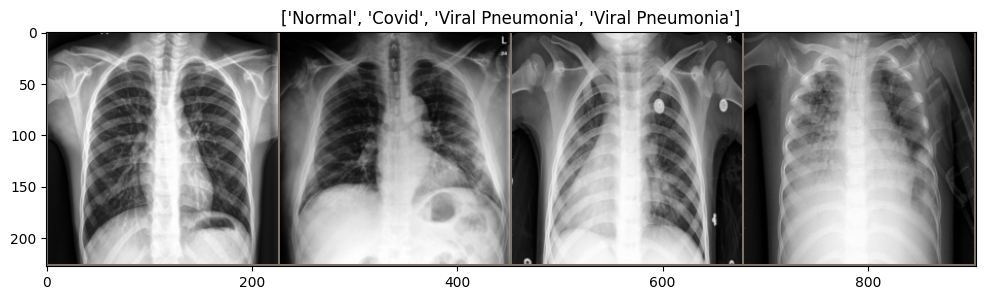

In [30]:
def imshow(inpt, title=None):
    inpt = inpt.numpy().transpose((1,2,0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inpt = std * inpt + mean
    inpt = np.clip(inpt, 0, 1)

    plt.figure(figsize=(12,6))
    plt.imshow(inpt)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pause a bit so that plots are updated

# Get a batch of training data
inputs, classes = next(iter(train_loader))
out = torchvision.utils.make_grid(inputs[:4])
imshow(out, title=[train_data.classes[x] for x in classes[:4]])

Loading the ResNet50

In [32]:
model = models.resnet50(pretrained=True)
print(model)
for param in model.parameters():
    param.requires_grad = False


c:\Users\admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [33]:
in_featurs = model.fc.in_features
model.fc = nn.Linear(in_featurs, num_classes)
model = model.to(device)
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

Defining the criterion and Optimizer

In [34]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=learning_rate)

training Loop

In [37]:
def train(model, train_loader, test_loader, criterion, optimizer, device,num_epochs):
    train_acc, test_acc = [], []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        for inputs, labels in tqdm.tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}'):
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs,1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_accuracy = 100 * correct / total
        train_acc.append(train_accuracy)

        # Evaluate on test data
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, predicted = torch.max(outputs,1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        test_accuracy = 100 * correct / total
        test_acc.append(test_accuracy)

        print(f"Epoch [{epoch+1}/{num_epochs}] | Loss: {running_loss/len(train_loader):.4f} | Train Acc: {train_accuracy:.2f}% | Val Acc: {test_accuracy:.2f}%")

    return train_acc, test_acc

In [38]:
train_acc, test_acc = train(model, train_loader, test_loader, criterion, optimizer, device, num_epochs)

Epoch 1/10: 100%|██████████| 8/8 [00:36<00:00,  4.55s/it]


Epoch [1/10] | Loss: 1.1207 | Train Acc: 39.84% | Val Acc: 50.00%


Epoch 2/10: 100%|██████████| 8/8 [00:31<00:00,  3.99s/it]


Epoch [2/10] | Loss: 0.7320 | Train Acc: 77.69% | Val Acc: 81.82%


Epoch 3/10: 100%|██████████| 8/8 [00:29<00:00,  3.73s/it]


...

Epoch [8/10] | Loss: 0.2596 | Train Acc: 94.82% | Val Acc: 90.91%


Epoch 9/10: 100%|██████████| 8/8 [00:22<00:00,  2.85s/it]


Epoch [9/10] | Loss: 0.2703 | Train Acc: 92.43% | Val Acc: 90.91%


Epoch 10/10: 100%|██████████| 8/8 [00:23<00:00,  2.91s/it]


Epoch [10/10] | Loss: 0.2265 | Train Acc: 94.82% | Val Acc: 90.91%


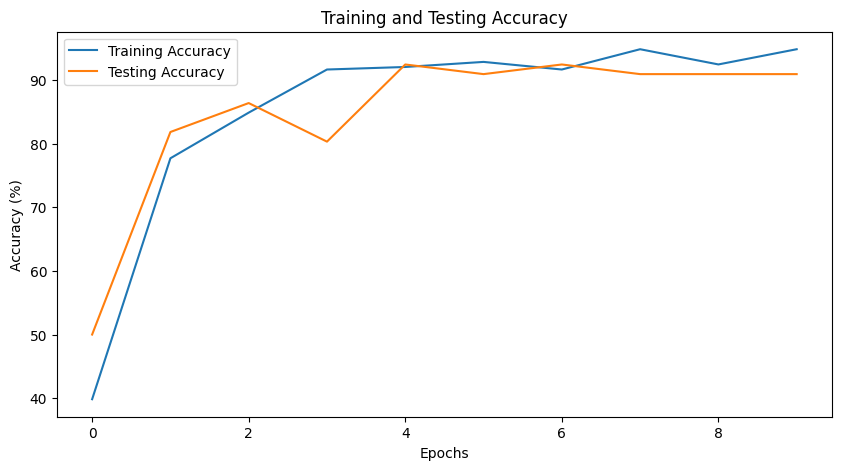

In [39]:
plt.figure(figsize=(10,5))
plt.plot(train_acc, label = 'Training Accuracy')
plt.plot(test_acc, label = 'Testing Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.title('Training and Testing Accuracy')
plt.legend()
plt.show()


Classification Report:

                 precision    recall  f1-score   support

          Covid       1.00      1.00      1.00        26
         Normal       0.85      0.85      0.85        20
Viral Pneumonia       0.85      0.85      0.85        20

       accuracy                           0.91        66
      macro avg       0.90      0.90      0.90        66
   weighted avg       0.91      0.91      0.91        66



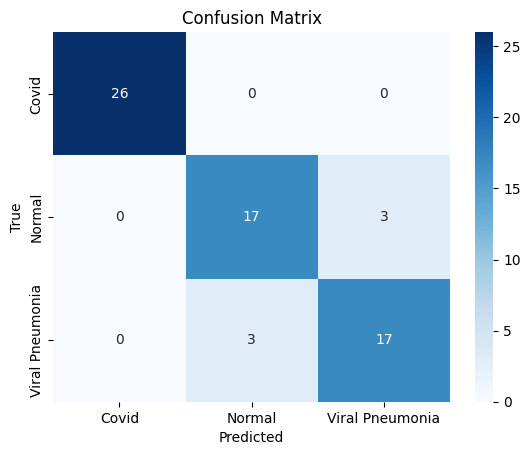

In [40]:
# ============================================================
# Evaluation
# ============================================================
y_true, y_pred = [], []
model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        y_true.extend(labels.numpy())
        y_pred.extend(predicted.cpu().numpy())

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=train_data.classes))

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=train_data.classes, yticklabels=train_data.classes)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()
